Train shape: (60000, 28, 28) (60000,)
Test shape: (10000, 28, 28) (10000,)


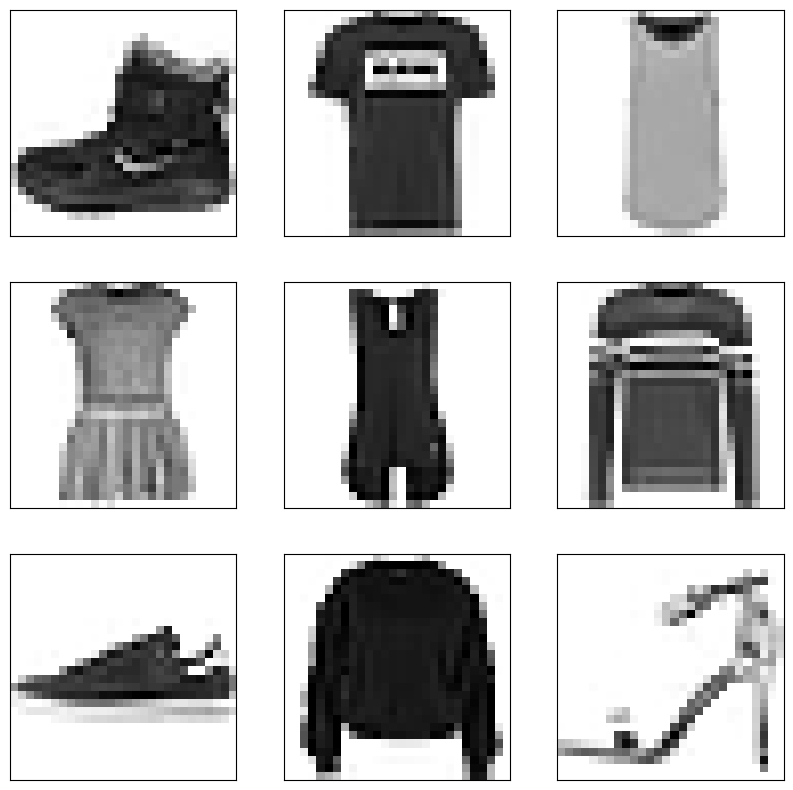

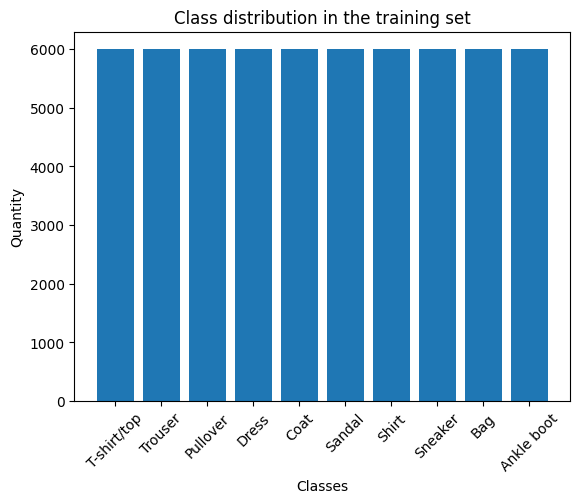

Normalized train shape: (60000, 28, 28, 1)
Normalized test shape: (10000, 28, 28)


In [ ]:
from keras import activations
from keras.layers import Activation
from keras.src.optimizers import optimizer
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras


#loading of dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("Train shape:", x_train.shape, y_train.shape)
print("Test shape:", x_test.shape, y_test.shape)

#Adding class names for better understanding
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

#visualization
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

#Plot class distribution
unique, counts = np.unique(y_train, return_counts=True)
plt.bar(class_names, counts)
plt.title('Class distribution in the training set')
plt.xlabel('Classes')
plt.ylabel('Quantity')
plt.xticks(rotation=45)
plt.show()

#normalize of pixels
x_train = x_train / 255.0
x_test = x_test / 255.0

#Reshape for CNN
x_train = x_train.reshape(-1, 28, 28, 1)
x_tesr = x_test.reshape(-1, 28, 28, 1)

print("Normalized train shape:", x_train.shape)
print("Normalized test shape:", x_test.shape)

#Creating model
model = keras.Sequatnial([
    keras.layers.Conv2D(32, (3, 3), activation='relu', imput_shape=(28, 28, 1)),
    keras.layers.MaxPoling2D((2, 2)),
    keras.layers.Conv2D(64, (3, 3), activation='relu'),
    keras.layers.MaxPoling2D((2, 2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')
])

